In [1]:
# %% [markdown]
# # 04 — Churn Prediction (XGBoost + SHAP)
# ## RetailPulse — Zidio Development | March 2026


In [2]:
# %%[markdown]
# ## Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

In [4]:
# %%[markdown]
# ## Load Data & Build Churn Features

In [5]:
sales = pd.read_parquet('../data/processed/sales_clean.parquet')
rfm = pd.read_csv('../data/processed/rfm_segments.csv')

print(f"Sales: {len(sales):,} rows")
print(f"RFM: {len(rfm):,} customers")

Sales: 779,425 rows
RFM: 5,878 customers


In [6]:
# %%[markdown]
# ## Define Churn (90-day threshold)

In [7]:
snapshot_date = sales['date'].max()
churn_threshold = 90
rfm['Churned'] = (rfm['Recency'] > churn_threshold).astype(int)
print(f"Churn rate: {rfm['Churned'].mean()*100:.1f}%")
print(f"Churned: {rfm['Churned'].sum():,} / {len(rfm):,}")

Churn rate: 50.9%
Churned: 2,989 / 5,878


In [8]:
# %%[markdown]
# ## Additional Behavioral Features

In [9]:
customer_features = sales.groupby('customer_id').agg(
    avg_basket_size=('revenue', 'mean'),
    std_basket_size=('revenue', 'std'),
    total_items=('quantity', 'sum'),
    unique_products=('product_id', 'nunique'),
    total_transactions=('transaction_id', 'nunique'),
    days_active=('date', lambda x: (x.max() - x.min()).days)
).reset_index()

churn_df = rfm.merge(customer_features, on='customer_id', how='left').fillna(0)

feature_cols = ['Recency', 'Frequency', 'Monetary', 'RFM_Score',
                'avg_basket_size', 'std_basket_size', 'total_items',
                'unique_products', 'total_transactions', 'days_active']

X = churn_df[feature_cols]
y = churn_df['Churned']

print(f"Feature matrix: {X.shape}")
print(f"Features: {feature_cols}")

Feature matrix: (5878, 10)
Features: ['Recency', 'Frequency', 'Monetary', 'RFM_Score', 'avg_basket_size', 'std_basket_size', 'total_items', 'unique_products', 'total_transactions', 'days_active']


In [10]:
# %%[markdown]
# ## Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")

Train: 4702, Test: 1176
Train churn rate: 50.9%


In [12]:
# %%[markdown]
# ## XGBoost Baseline

In [13]:
model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric='auc'
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC: {auc:.4f}")
print(f"Within target (≥0.88): {auc >= 0.88}")
print(f"\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))

threshold = np.percentile(y_pred_proba, 80)
top20_mask = y_pred_proba >= threshold
precision_top20 = y_test[top20_mask].mean()
print(f"Precision@Top20%: {precision_top20:.4f}")

[0]	validation_0-auc:0.95874


[50]	validation_0-auc:1.00000


[100]	validation_0-auc:1.00000


[150]	validation_0-auc:1.00000


[200]	validation_0-auc:1.00000


[250]	validation_0-auc:1.00000


[299]	validation_0-auc:1.00000



AUC-ROC: 1.0000
Within target (≥0.88): True

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

Precision@Top20%: 1.0000


In [14]:
# %%[markdown]
# ## SHAP Explainability

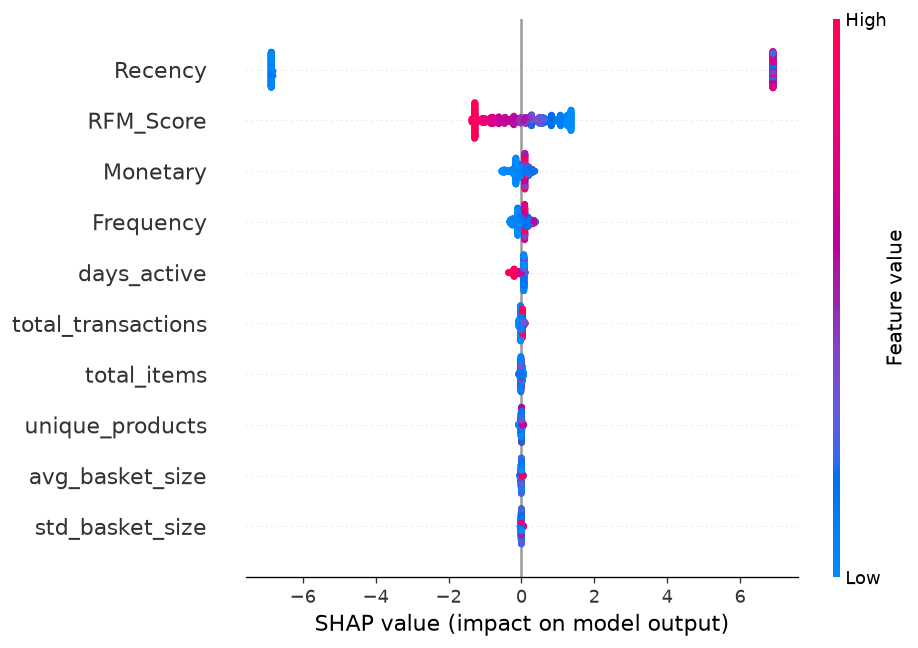

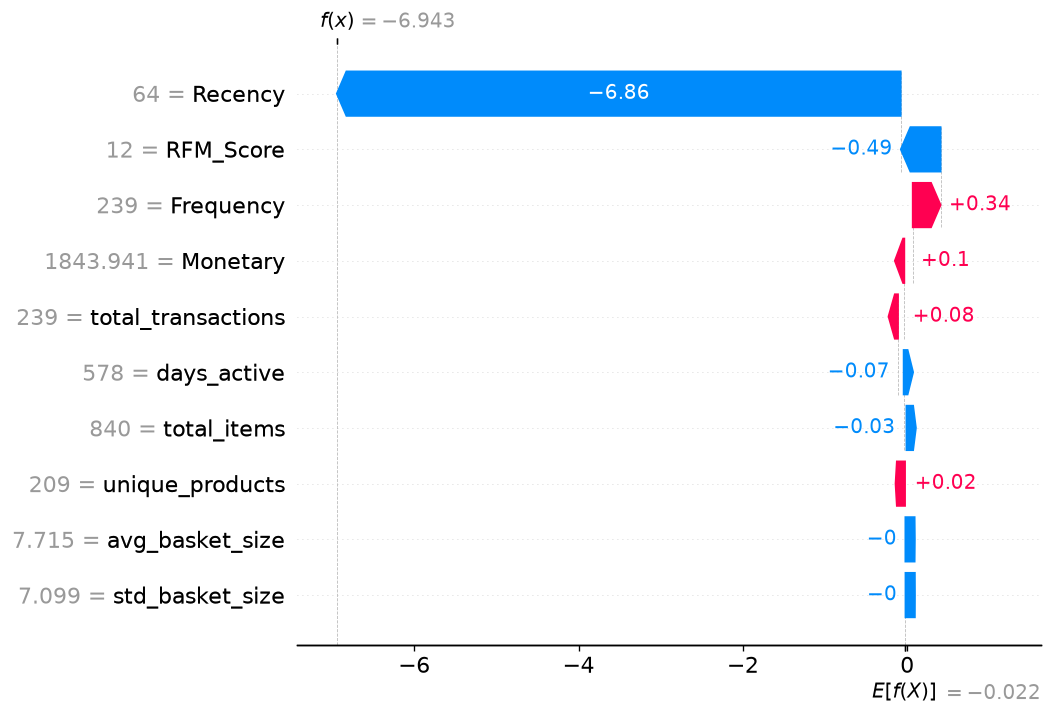

<Figure size 768x576 with 0 Axes>

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', bbox_inches='tight')
plt.show()

# Waterfall for first prediction
shap.initjs()
plt.figure()
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=feature_cols
))
plt.savefig('../reports/shap_waterfall.png', bbox_inches='tight')
plt.show()

In [16]:
# %%[markdown]
# ## Save Churn Scores & Model

In [17]:
churn_df['Churn_Probability'] = model.predict_proba(X)[:, 1]
churn_df['Churn_Risk'] = pd.cut(churn_df['Churn_Probability'],
                                 bins=[0, 0.3, 0.6, 1.0],
                                 labels=['Low', 'Medium', 'High'])

churn_df.to_csv('../data/processed/churn_scores.csv', index=False)
print(f"Saved churn_scores.csv with {len(churn_df)} customers")

import joblib
joblib.dump(model, '../data/processed/models/churn_model.pkl')
print("Saved churn_model.pkl")

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.to_csv('../data/processed/churn_importance.csv', index=False)
print("Saved churn_importance.csv")
print(f"\nTop 5 features:")
print(importance_df.head())

Saved churn_scores.csv with 5878 customers
Saved churn_model.pkl
Saved churn_importance.csv

Top 5 features:
       feature  importance
0      Recency    0.840189
3    RFM_Score    0.060695
9  days_active    0.020614
1    Frequency    0.019374
6  total_items    0.015139
